In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# for better visuals
sns.set(style="whitegrid")
df = pd.read_csv(r"E:\Supervised Project\data\data.csv", encoding='ISO-8859-1')


In [17]:
import os
print(os.getcwd())

e:\Supervised Project\jupyter


In [18]:
rfm = pd.read_csv("../data/rfm.csv")

In [19]:
rfm['HighValue'] = (rfm['Monetary'] > rfm['Monetary'].median()).astype(int)

In [20]:
from sklearn.model_selection import train_test_split

X = rfm[['Recency','Frequency','Monetary']]
y = rfm['HighValue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.model_selection import train_test_split

X = rfm[['Recency','Frequency','Monetary']]
y = rfm['HighValue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [23]:
best_model = grid.best_estimator_

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9988479262672811
Confusion Matrix:
 [[429   0]
 [  1 438]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       429
           1       1.00      1.00      1.00       439

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



In [25]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=5)

print("Cross Validation Score:", cv_scores.mean())

Cross Validation Score: 0.9997695852534563


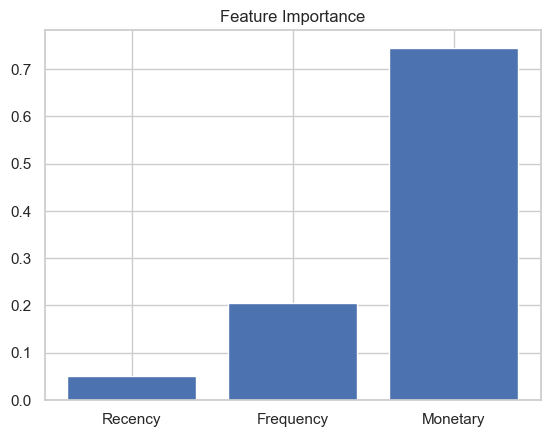

In [26]:
import matplotlib.pyplot as plt

importances = best_model.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

In [29]:
import joblib

joblib.dump(best_model, "../models/classifier_tuned.pkl")

['../models/classifier_tuned.pkl']